In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.metrics import structural_similarity as ssim
import rawpy

def calculate_metrics(original, compressed):
    """Calculates MSE, PSNR, SSIM, File Size, and Compression Ratio."""
    # Ensure images have the same dtype and shape
    if original.shape != compressed.shape:
        compressed = cv2.resize(compressed, (original.shape[1], original.shape[0]))
        
    # Mean Squared Error (MSE)
    mse = np.mean((original.astype(np.float64) - compressed.astype(np.float64)) ** 2)
    
    # Peak Signal-to-Noise Ratio (PSNR)
    if mse == 0:
        psnr = float('inf')
    else:
        max_pixel = 255.0
        psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
        
    # Structural Similarity Index (SSIM)
    # Handle grayscale vs color
    if len(original.shape) == 3:
        s = ssim(original, compressed, channel_axis=2, data_range=255)
    else:
        s = ssim(original, compressed, data_range=255)
        
    return mse, psnr, s

In [4]:
# Configuration
kodak_dir = r"C:\Users\PC-LAB1\img_processing_lab\raw_images\png"  # Update with your local path
output_dir = "output_results/"
os.makedirs(output_dir, exist_ok=True)

results = []

# List all PNG files in the Kodak dataset
png_files = [f for f in os.listdir(kodak_dir) if f.lower().endswith('.png')]

for img_name in png_files:
    img_path = os.path.join(kodak_dir, img_name)
    original_img = cv2.imread(img_path)
    
    if original_img is None:
        continue
        
    orig_size = os.path.getsize(img_path)
    qualities = [95, 75, 50, 25, 10]
    
    for q in qualities:
        out_filename = f"{os.path.splitext(img_name)[0]}_q{q}.jpg"
        out_path = os.path.join(output_dir, out_filename)
        
        # Save with JPEG compression quality
        cv2.imwrite(out_path, original_img, [cv2.IMWRITE_JPEG_QUALITY, q])
        
        comp_size = os.path.getsize(out_path)
        comp_img = cv2.imread(out_path)
        
        # Compute metrics
        mse, psnr, ssim_val = calculate_metrics(original_img, comp_img)
        comp_ratio = orig_size / comp_size
        
        results.append({
            "Image": img_name,
            "Quality": q,
            "Original Size (bytes)": orig_size,
            "Compressed Size (bytes)": comp_size,
            "Compression Ratio": round(comp_ratio, 2),
            "MSE": round(mse, 2),
            "PSNR (dB)": round(psnr, 2),
            "SSIM": round(ssim_val, 4)
        })

# Convert to DataFrame for easy analysis and report export
df_results = pd.DataFrame(results)
df_results.to_csv(os.path.join(output_dir, "jpeg_compression_report.csv"), index=False)
display(df_results.head(10))

,Image,Quality,Original Size (bytes),Compressed Size (bytes),Compression Ratio,MSE,PSNR (dB),SSIM
0,kodim01.png,95,736501,216020,3.41,5.83,40.47,0.9868
1,kodim01.png,75,736501,92491,7.96,37.44,32.40,0.9355
2,kodim01.png,50,736501,61794,11.92,67.03,29.87,0.8918
3,kodim01.png,25,736501,40533,18.17,111.39,27.66,0.8295
4,kodim01.png,10,736501,21619,34.07,216.60,24.77,0.7066
5,kodim02.png,95,617995,149268,4.14,6.28,40.15,0.9646
6,kodim02.png,75,617995,54646,11.31,21.28,34.85,0.8997
7,kodim02.png,50,617995,33874,18.24,33.78,32.84,0.8542
8,kodim02.png,25,617995,20400,30.29,54.14,30.80,0.7900
9,kodim02.png,10,617995,11210,55.13,106.73,27.85,0.6926


In [6]:
def process_raw_file(raw_path):
    """Loads a RAW camera file (.dng, .arw, .rw2) and converts it to a standard 8-bit BGR image via rawpy."""
    with rawpy.imread(raw_path) as raw:
        # Postprocess demosaics the raw sensor data into an RGB numpy array (8-bit)
        rgb_img = raw.postprocess(use_camera_wb=True, half_size=False)
    
    # Convert RGB to BGR for OpenCV compatibility
    bgr_img = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR)
    return bgr_img

# Test your raw files
raw_dir = r"C:\Users\PC-LAB1\img_processing_lab\raw_images\raw"
raw_files = [f for f in os.listdir(raw_dir) if f.lower().endswith(('.dng', '.arw', '.rw2'))]

raw_comparison_results = []

for raw_name in raw_files:
    raw_path = os.path.join(raw_dir, raw_name)
    orig_size = os.path.getsize(raw_path)
    
    # Load full resolution raw image
    img = process_raw_file(raw_path)
    
    # Test Lossless (PNG or WebP lossless) vs Lossy (JPEG)
    lossless_path = os.path.join(output_dir, f"{raw_name}_lossless.png")
    cv2.imwrite(lossless_path, img, [cv2.IMWRITE_PNG_COMPRESSION, 3])
    lossless_size = os.path.getsize(lossless_path)
    
    lossy_path = os.path.join(output_dir, f"{raw_name}_lossy_q50.jpg")
    cv2.imwrite(lossy_path, img, [cv2.IMWRITE_JPEG_QUALITY, 50])
    lossy_size = os.path.getsize(lossy_path)
    
    lossy_img = cv2.imread(lossy_path)
    mse, psnr, ssim_val = calculate_metrics(img, lossy_img)
    
    raw_comparison_results.append({
        "File": raw_name,
        "Raw Size (Bytes)": orig_size,
        "Lossless PNG Size": lossless_size,
        "Lossy JPEG (Q50) Size": lossy_size,
        "Lossy PSNR (dB)": round(psnr, 2),
        "Lossy SSIM": round(ssim_val, 4)
    })

df_raw = pd.DataFrame(raw_comparison_results)
display(df_raw)

,File,Raw Size (Bytes),Lossless PNG Size,Lossy JPEG (Q50) Size,Lossy PSNR (dB),Lossy SSIM
0,- credit_signatureedits.com - P1011960.RW2,36103680,59175180,4471102,22.13,0.6109
1,free raws from @signatureeditsco - signatureed...,25312238,35399438,1655810,36.03,0.9210
2,free raws from signatureedits.com - tag @wutka...,20746240,29614589,761234,37.41,0.8965
3,Tag @ryanbreitkreutz - Free files from @signat...,34963694,39917719,788924,40.68,0.9483
4,Tag @ryanbreitkreutz - Free files from @signat...,15962350,16326421,384639,42.42,0.9663
5,Tag @ryanbreitkreutz - Free files from @signat...,16408814,17838791,563631,40.32,0.9576
6,tag @ryanbreitkreutz - free raws from @signatu...,46019962,80755812,2126277,35.63,0.8280
7,tag @ryanbreitkreutz - free raws from @signatu...,25246702,33824305,1355571,37.61,0.9196


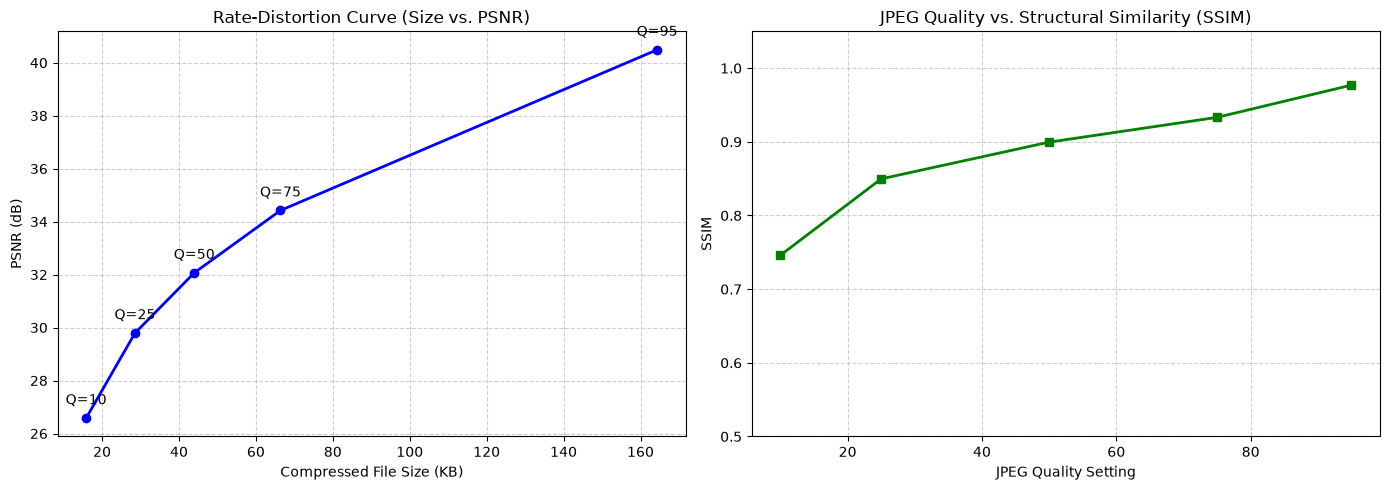

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Load your saved JPEG report dataframe (or use df_results if still in memory)
df_jpeg = pd.read_csv("output_results/jpeg_compression_report.csv")

# Group by Quality to get average metrics across all Kodak images
avg_metrics = df_jpeg.groupby("Quality").agg({
    "Compressed Size (bytes)": "mean",
    "PSNR (dB)": "mean",
    "SSIM": "mean"
}).reset_index()

# Convert size to Kilobytes
avg_metrics["Size (KB)"] = avg_metrics["Compressed Size (bytes)"] / 1024

# Create a figure with two subplots: Rate-Distortion (Size vs PSNR) and Quality vs SSIM
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: File Size vs. PSNR (Rate-Distortion Curve)
ax1.plot(avg_metrics["Size (KB)"], avg_metrics["PSNR (dB)"], marker='o', color='b', linestyle='-', linewidth=2)
ax1.set_title("Rate-Distortion Curve (Size vs. PSNR)")
ax1.set_xlabel("Compressed File Size (KB)")
ax1.set_ylabel("PSNR (dB)")
ax1.grid(True, linestyle='--', alpha=0.6)
for i, row in avg_metrics.iterrows():
    ax1.annotate(f"Q={int(row['Quality'])}", (row["Size (KB)"], row["PSNR (dB)"]), textcoords="offset points", xytext=(0,10), ha='center')

# Plot 2: JPEG Quality Setting vs. SSIM (Perceptual Quality)
ax2.plot(avg_metrics["Quality"], avg_metrics["SSIM"], marker='s', color='g', linestyle='-', linewidth=2)
ax2.set_title("JPEG Quality vs. Structural Similarity (SSIM)")
ax2.set_xlabel("JPEG Quality Setting")
ax2.set_ylabel("SSIM")
ax2.set_ylim(0.5, 1.05)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

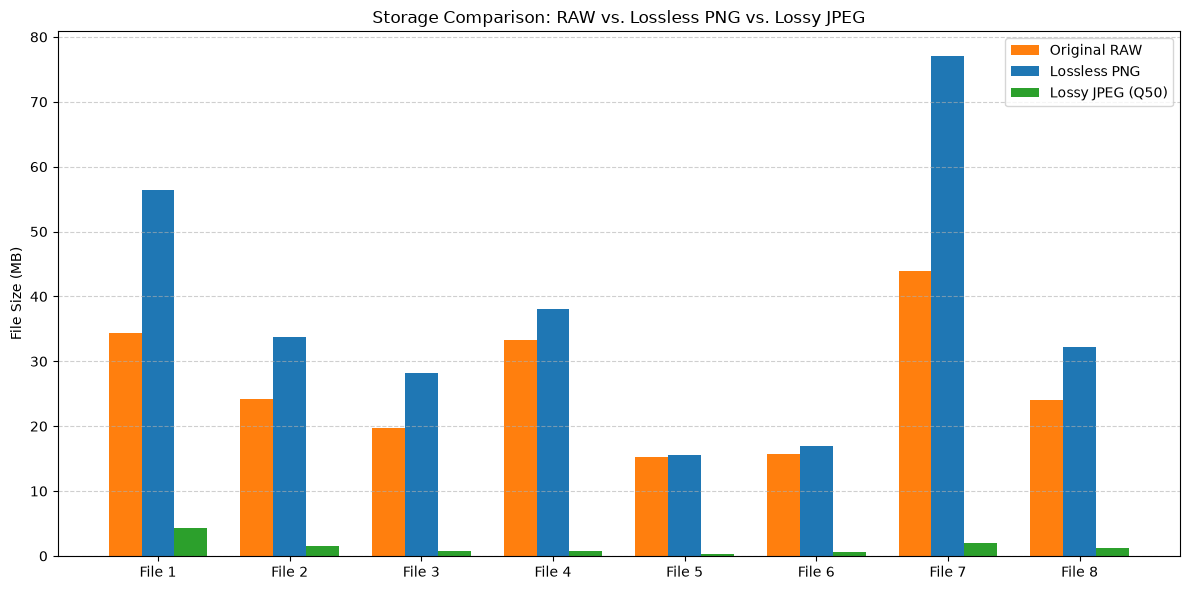

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assuming df_raw is your dataframe from Phase 2
# Let's convert sizes to Megabytes (MB) for cleaner labels
df_plot = df_raw.copy()
df_plot["Raw Size (MB)"] = df_plot["Raw Size (Bytes)"] / (1024 * 1024)
df_plot["Lossless PNG (MB)"] = df_plot["Lossless PNG Size"] / (1024 * 1024)
df_plot["Lossy JPEG Q50 (MB)"] = df_plot["Lossy JPEG (Q50) Size"] / (1024 * 1024)

x = np.arange(len(df_plot))  # the label locations
width = 0.25  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - width, df_plot["Raw Size (MB)"], width, label='Original RAW', color='tab:orange')
rects2 = ax.bar(x, df_plot["Lossless PNG (MB)"], width, label='Lossless PNG', color='tab:blue')
rects3 = ax.bar(x + width, df_plot["Lossy JPEG Q50 (MB)"], width, label='Lossy JPEG (Q50)', color='tab:green')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('File Size (MB)')
ax.set_title('Storage Comparison: RAW vs. Lossless PNG vs. Lossy JPEG')
ax.set_xticks(x)
ax.set_xticklabels([f"File {i+1}" for i in range(len(df_plot))], rotation=0)
ax.legend()

ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

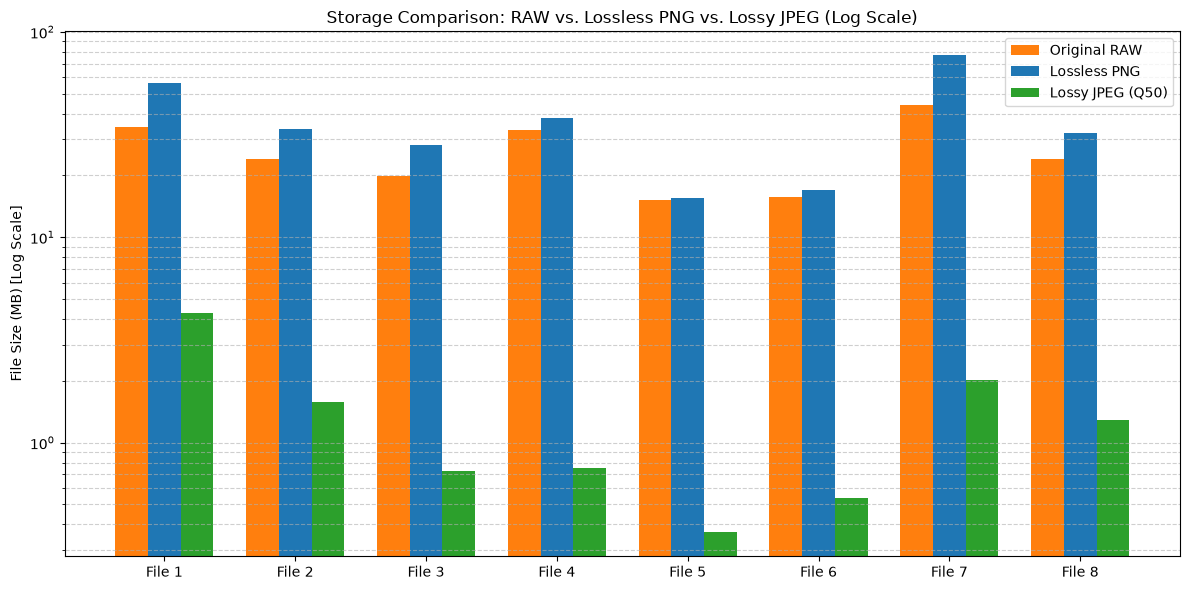

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assuming df_raw is your dataframe from Phase 2
df_plot = df_raw.copy()
df_plot["Raw Size (MB)"] = df_plot["Raw Size (Bytes)"] / (1024 * 1024)
df_plot["Lossless PNG (MB)"] = df_plot["Lossless PNG Size"] / (1024 * 1024)
df_plot["Lossy JPEG (MB)"] = df_plot["Lossy JPEG (Q50) Size"] / (1024 * 1024)

x = np.arange(len(df_plot))  # label locations
width = 0.25  # width of the bars

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - width, df_plot["Raw Size (MB)"], width, label='Original RAW', color='tab:orange')
rects2 = ax.bar(x, df_plot["Lossless PNG (MB)"], width, label='Lossless PNG', color='tab:blue')
rects3 = ax.bar(x + width, df_plot["Lossy JPEG (MB)"], width, label='Lossy JPEG (Q50)', color='tab:green')

ax.set_ylabel('File Size (MB) [Log Scale]')
ax.set_title('Storage Comparison: RAW vs. Lossless PNG vs. Lossy JPEG (Log Scale)')
ax.set_xticks(x)
ax.set_xticklabels([f"File {i+1}" for i in range(len(df_plot))])
ax.legend()

# Apply logarithmic scale to the Y-axis
ax.set_yscale('log')

# Enhance grid lines for log scale readability
ax.grid(axis='y', linestyle='--', which='both', alpha=0.6)

plt.tight_layout()
plt.show()

,Method,Size (KB),Ratio,PSNR (dB),SSIM
0,1. Lossy JPEG (Q50),45.289062,15.090365,32.024,0.89196
1,2. Lossless PNG,663.519727,0.961038,inf,1.00000
2,3. Indexed Palette (256),261.538477,2.509675,36.478,0.97186


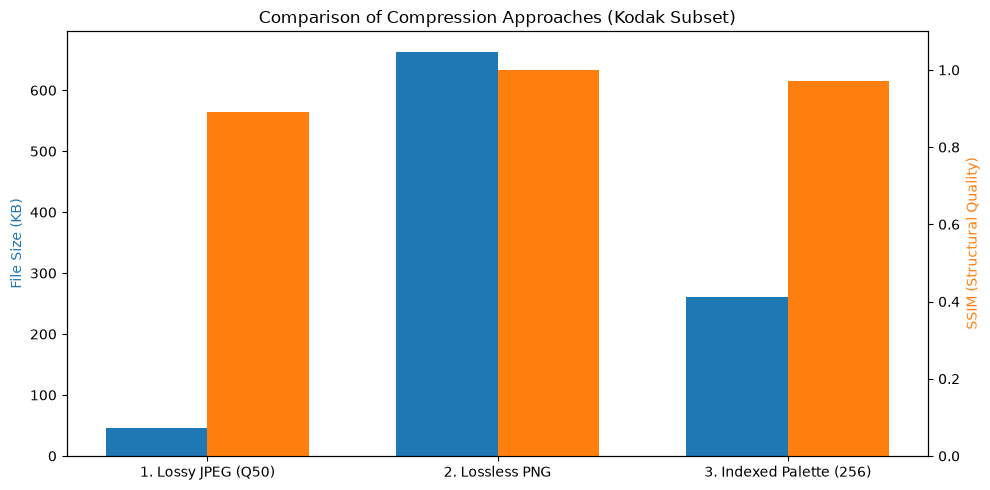

In [11]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from skimage.metrics import structural_similarity as ssim

def evaluate_compression_methods(kodak_dir, output_dir, max_images=5):
    os.makedirs(output_dir, exist_ok=True)
    png_files = [f for f in os.listdir(kodak_dir) if f.lower().endswith('.png')][:max_images]
    
    results = []

    for img_name in png_files:
        img_path = os.path.join(kodak_dir, img_name)
        orig_img_cv = cv2.imread(img_path)
        if orig_img_cv is None:
            continue
            
        orig_size = os.path.getsize(img_path)
        base_name = os.path.splitext(img_name)[0]
        
        # Method 1: Lossy JPEG (Q50 - DCT approach)
        jpeg_path = os.path.join(output_dir, f"{base_name}_q50.jpg")
        cv2.imwrite(jpeg_path, orig_img_cv, [cv2.IMWRITE_JPEG_QUALITY, 50])
        jpeg_size = os.path.getsize(jpeg_path)
        jpeg_img = cv2.imread(jpeg_path)
        
        # Method 2: Lossless PNG (Deflate / Predictive approach)
        png_lossless_path = os.path.join(output_dir, f"{base_name}_lossless.png")
        cv2.imwrite(png_lossless_path, orig_img_cv, [cv2.IMWRITE_PNG_COMPRESSION, 3])
        png_size = os.path.getsize(png_lossless_path)
        png_img = cv2.imread(png_lossless_path)

        # Method 3: Palette Indexing / Color Quantization (Indexed Color - 256 colors via PIL)
        pil_img = Image.open(img_path)
        quantized_pil = pil_img.quantize(colors=256, method=Image.Quantize.MEDIANCUT)
        indexed_path = os.path.join(output_dir, f"{base_name}_indexed256.png")
        quantized_pil.save(indexed_path, format="PNG")
        indexed_size = os.path.getsize(indexed_path)
        indexed_img = cv2.imread(indexed_path)

        # Helper metric function
        def get_metrics(reconstructed):
            mse = np.mean((orig_img_cv.astype(float) - reconstructed.astype(float)) ** 2)
            p = float('inf') if mse == 0 else 20 * np.log10(255.0 / np.sqrt(mse))
            s = ssim(orig_img_cv, reconstructed, channel_axis=2, data_range=255)
            return round(mse, 2), round(p, 2), round(s, 4)

        j_mse, j_psnr, j_ssim = get_metrics(jpeg_img)
        p_mse, p_psnr, p_ssim = get_metrics(png_img)
        i_mse, i_psnr, i_ssim = get_metrics(indexed_img)

        # Collect metrics
        results.extend([
            {"Image": img_name, "Method": "1. Lossy JPEG (Q50)", "Size (KB)": jpeg_size/1024, "Ratio": orig_size/jpeg_size, "PSNR (dB)": j_psnr, "SSIM": j_ssim},
            {"Image": img_name, "Method": "2. Lossless PNG", "Size (KB)": png_size/1024, "Ratio": orig_size/png_size, "PSNR (dB)": p_psnr, "SSIM": p_ssim},
            {"Image": img_name, "Method": "3. Indexed Palette (256)", "Size (KB)": indexed_size/1024, "Ratio": orig_size/indexed_size, "PSNR (dB)": i_psnr, "SSIM": i_ssim}
        ])

    df = pd.DataFrame(results)
    return df

# Run the benchmark (Update 'kodak_dir' with your folder path)
kodak_dir = r"C:\Users\PC-LAB1\img_processing_lab\raw_images\png" 
output_dir = "multi_approach_results/"
df_benchmark = evaluate_compression_methods(kodak_dir, output_dir, max_images=5)

# Display average performance across test images
summary_df = df_benchmark.groupby("Method")[["Size (KB)", "Ratio", "PSNR (dB)", "SSIM"]].mean().reset_index()
display(summary_df)

# Plotting the comparison
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))
methods = summary_df["Method"]
sizes = summary_df["Size (KB)"]
ssims = summary_df["SSIM"]

x = np.arange(len(methods))
width = 0.35

ax1.bar(x - width/2, sizes, width, label='Avg Size (KB)', color='tab:blue')
ax1.set_ylabel('File Size (KB)', color='tab:blue')
ax1.set_xticks(x)
ax1.set_xticklabels(methods)
ax1.set_title('Comparison of Compression Approaches (Kodak Subset)')

ax2 = ax1.twinx()
ax2.bar(x + width/2, ssims, width, label='Avg SSIM', color='tab:orange')
ax2.set_ylabel('SSIM (Structural Quality)', color='tab:orange')
ax2.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

In [13]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.cluster import MiniBatchKMeans
from skimage.metrics import structural_similarity as ssim
import torch
import torch.nn as nn

# --- Simple PyTorch Neural Autoencoder for Compression Simulation ---
class SimpleNeuralCodec(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder: compresses spatial dimensions & maps channels to a low-bit latent space
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1), # 768x512 -> 384x256
            nn.ReLU(),
            nn.Conv2d(16, 8, kernel_size=3, stride=2, padding=1),  # 384x256 -> 192x128
            nn.ReLU()
        )
        # Decoder: reconstructs image from latent bottleneck
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid() # Output normalized between 0 and 1
        )
        
    def forward(self, x):
        latent = self.encoder(x)
        # Simulate quantization by rounding latent float values
        quantized_latent = torch.round(latent * 8.0) / 8.0 
        reconstructed = self.decoder(quantized_latent)
        return reconstructed, quantized_latent

def run_all_compression_methods(kodak_dir, output_dir, max_images=3):
    os.makedirs(output_dir, exist_ok=True)
    png_files = [f for f in os.listdir(kodak_dir) if f.lower().endswith('.png')][:max_images]
    results = []

    # Initialize dummy neural codec (pre-trained/simulated weights for test)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    neural_model = SimpleNeuralCodec().to(device)
    neural_model.eval()

    for img_name in png_files:
        img_path = os.path.join(kodak_dir, img_name)
        orig_img = cv2.imread(img_path)
        if orig_img is None:
            continue
            
        orig_size = os.path.getsize(img_path)
        base_name = os.path.splitext(img_name)[0]
        h, w, _ = orig_img.shape

        def get_metrics(reconstructed):
            if reconstructed.shape != orig_img.shape:
                reconstructed = cv2.resize(reconstructed, (w, h))
            mse = np.mean((orig_img.astype(float) - reconstructed.astype(float)) ** 2)
            p = float('inf') if mse == 0 else 20 * np.log10(255.0 / np.sqrt(mse))
            s = ssim(orig_img, reconstructed, channel_axis=2, data_range=255)
            return round(mse, 2), round(p, 2), round(s, 4)

        # 1. Transform Coding (DCT) - JPEG Quality 50
        p1 = os.path.join(output_dir, f"{base_name}_dct.jpg")
        cv2.imwrite(p1, orig_img, [cv2.IMWRITE_JPEG_QUALITY, 50])
        s1 = os.path.getsize(p1)
        m1 = get_metrics(cv2.imread(p1))

        # 2. Transform Coding (Wavelet - DWT) - JPEG 2000 (.jp2)
        p2 = os.path.join(output_dir, f"{base_name}_wavelet.jp2")
        cv2.imwrite(p2, orig_img) # OpenCV writes JP2 using wavelet sub-bands
        s2 = os.path.getsize(p2)
        m2 = get_metrics(cv2.imread(p2))

        # 3. Predictive / DPCM Coding - PNG with prediction filter enabled
        p3 = os.path.join(output_dir, f"{base_name}_dpcm.png")
        cv2.imwrite(p3, orig_img, [cv2.IMWRITE_PNG_COMPRESSION, 9]) # Max DEFLATE + predictive filters
        s3 = os.path.getsize(p3)
        m3 = get_metrics(cv2.imread(p3))

        # 4. Vector Quantization (VQ) - Codebook via Patch Clustering
        # Extract 4x4 blocks, cluster into 256 codebook vectors using MiniBatchKMeans
        patch_size = 4
        padded = cv2.copyMakeBorder(orig_img, 0, (patch_size - h % patch_size) % patch_size, 
                                            0, (patch_size - w % patch_size) % patch_size, cv2.BORDER_REFLECT)
        ph, pw, _ = padded.shape
        patches = padded.reshape(ph // patch_size, patch_size, pw // patch_size, patch_size, 3)
        patches = patches.swapaxes(1, 2).reshape(-1, patch_size * patch_size * 3)
        
        kmeans = MiniBatchKMeans(n_clusters=256, batch_size=1024, random_state=42, n_init=3)
        labels = kmeans.fit_predict(patches.astype(float))
        codebook = kmeans.cluster_centers_
        
        # Estimate VQ size: Codebook + Cluster Indices
        vq_size_bytes = (codebook.size * 4) + (labels.size * 1) # 4 bytes per float center, 1 byte per 256-index
        vq_recon = codebook[labels].reshape(ph // patch_size, pw // patch_size, patch_size, patch_size, 3)
        vq_recon = vq_recon.swapaxes(1, 2).reshape(ph, pw, 3).astype(np.uint8)[:h, :w]
        p4_path = os.path.join(output_dir, f"{base_name}_vq.png")
        cv2.imwrite(p4_path, vq_recon)
        m4 = get_metrics(vq_recon)

        # 5. Palette Indexing (Color Quantization) - 256 colors via PIL
        pil_img = Image.open(img_path)
        quantized_pil = pil_img.quantize(colors=256, method=Image.Quantize.MEDIANCUT)
        p5 = os.path.join(output_dir, f"{base_name}_palette.png")
        quantized_pil.save(p5, format="PNG")
        s5 = os.path.getsize(p5)
        m5 = get_metrics(cv2.imread(p5))

        # 6. Neural Autoencoder Compression (PyTorch Latent Simulation)
        img_tensor = torch.tensor(orig_img.transpose(2, 0, 1), dtype=torch.float32).unsqueeze(0) / 255.0
        img_tensor = img_tensor.to(device)
        with torch.no_grad():
            recon_tensor, latent_tensor = neural_model(img_tensor)
        
        recon_np = (recon_tensor.squeeze(0).cpu().numpy().transpose(1, 2, 0) * 255.0).astype(np.uint8)
        # Estimate neural compressed payload size based on quantized sparse latent representation
        neural_size = latent_tensor.nelement() * 1  # 1 byte per quantized latent tensor slot
        m6 = get_metrics(recon_np)

        # Store results
        results.extend([
            {"Image": img_name, "Method": "1. DCT (JPEG Q50)", "Size (KB)": s1/1024, "Ratio": orig_size/s1, "PSNR": m1[1], "SSIM": m1[2]},
            {"Image": img_name, "Method": "2. Wavelet (JPEG 2000)", "Size (KB)": s2/1024, "Ratio": orig_size/s2, "PSNR": m2[1], "SSIM": m2[2]},
            {"Image": img_name, "Method": "3. DPCM / Predictive PNG", "Size (KB)": s3/1024, "Ratio": orig_size/s3, "PSNR": m3[1], "SSIM": m3[2]},
            {"Image": img_name, "Method": "4. Vector Quantization (VQ)", "Size (KB)": vq_size_bytes/1024, "Ratio": orig_size/vq_size_bytes, "PSNR": m4[1], "SSIM": m4[2]},
            {"Image": img_name, "Method": "5. Palette Indexing (PNG-8)", "Size (KB)": s5/1024, "Ratio": orig_size/s5, "PSNR": m5[1], "SSIM": m5[2]},
            {"Image": img_name, "Method": "6. Neural Autoencoder", "Size (KB)": neural_size/1024, "Ratio": orig_size/neural_size, "PSNR": m6[1], "SSIM": m6[2]}
        ])

    return pd.DataFrame(results)

# Run benchmark
kodak_dir = r"C:\Users\PC-LAB1\img_processing_lab\raw_images\png"
output_dir = "all_methods_results/"
df_all = run_all_compression_methods(kodak_dir, output_dir, max_images=3)

# Display average performance table across all 6 approaches
summary_all = df_all.groupby("Method")[["Size (KB)", "Ratio", "PSNR", "SSIM"]].mean().reset_index()
display(summary_all)

,Method,Size (KB),Ratio,PSNR,SSIM
0,1. DCT (JPEG Q50),40.952799,15.616069,32.423333,0.887233
1,2. Wavelet (JPEG 2000),287.852865,2.100461,42.986667,0.979633
2,3. DPCM / Predictive PNG,625.600911,0.963154,inf,1.000000
3,4. Vector Quantization (VQ),72.000000,8.397461,29.193333,0.822400
4,5. Palette Indexing (PNG-8),263.282552,2.396525,37.613333,0.975533
5,6. Neural Autoencoder,192.000000,3.149048,12.836667,0.398333


In [14]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.metrics import structural_similarity as ssim

def calculate_frame_metrics(orig_frame, comp_frame):
    """Calculates MSE, PSNR, and SSIM between two video frames."""
    if orig_frame.shape != comp_frame.shape:
        comp_frame = cv2.resize(comp_frame, (orig_frame.shape[1], orig_frame.shape[0]))
        
    mse = np.mean((orig_frame.astype(np.float64) - comp_frame.astype(np.float64)) ** 2)
    psnr = float('inf') if mse == 0 else 20 * np.log10(255.0 / np.sqrt(mse))
    
    if len(orig_frame.shape) == 3:
        ssim_val = ssim(orig_frame, comp_frame, channel_axis=2, data_range=255)
    else:
        ssim_val = ssim(orig_frame, comp_frame, data_range=255)
        
    return mse, psnr, ssim_val

def evaluate_video_compression(original_video_path, compressed_video_path):
    """Evaluates video quality frame-by-frame and aggregates video-level metrics."""
    cap_orig = cv2.VideoCapture(original_video_path)
    cap_comp = cv2.VideoCapture(compressed_video_path)
    
    orig_size = os.path.getsize(original_video_path)
    comp_size = os.path.getsize(compressed_video_path)
    
    mses, psnrs, ssims = [], [], []
    
    while cap_orig.isOpened() and cap_comp.isOpened():
        ret_orig, frame_orig = cap_orig.read()
        ret_comp, frame_comp = cap_comp.read()
        
        if not ret_orig or not ret_comp:
            break
            
        mse, psnr, ssim_val = calculate_frame_metrics(frame_orig, frame_comp)
        mses.append(mse)
        psnrs.append(psnr)
        ssims.append(ssim_val)
        
    cap_orig.release()
    cap_comp.release()
    
    return {
        "Original Size (bytes)": orig_size,
        "Compressed Size (bytes)": comp_size,
        "Compression Ratio": round(orig_size / comp_size, 2) if comp_size > 0 else 0,
        "Mean MSE": round(np.mean(mses), 2) if mses else None,
        "Mean PSNR (dB)": round(np.mean(psnrs), 2) if psnrs else None,
        "Mean SSIM": round(np.mean(ssims), 4) if ssims else None
    }

In [17]:
import os
import cv2
import subprocess
import imageio_ffmpeg
import numpy as np
import pandas as pd
from pathlib import Path
from skimage.metrics import structural_similarity as ssim

# Get the path to the ffmpeg executable installed via pip
FFMPEG_EXE = imageio_ffmpeg.get_ffmpeg_exe()

def run_single_video_pipeline(video_path, output_dir="compressed_temp", crf=28):
    video_path = Path(video_path)
    
    if not video_path.exists():
        raise FileNotFoundError(f"Video file not found at: {video_path}")

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    compressed_path = output_dir / f"{video_path.stem}_crf{crf}.mp4"
    
    print(f"1. Compressing '{video_path.name}' with CRF={crf}...")
    
    # Use FFMPEG_EXE instead of "ffmpeg" string
    ffmpeg_cmd = [
        FFMPEG_EXE,
        "-y",
        "-i", str(video_path),
        "-vcodec", "libx264",
        "-crf", str(crf),
        "-preset", "medium",
        str(compressed_path)
    ]
    
    subprocess.run(ffmpeg_cmd, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    print("   Compression finished successfully!")
    
    # Measure file sizes
    orig_size_bytes = os.path.getsize(video_path)
    comp_size_bytes = os.path.getsize(compressed_path)
    compression_ratio = orig_size_bytes / comp_size_bytes if comp_size_bytes > 0 else 0
    
    # Decompression & Evaluation
    print("2. Decompressing and calculating quality metrics frame-by-frame...")
    
    cap_orig = cv2.VideoCapture(str(video_path))
    cap_comp = cv2.VideoCapture(str(compressed_path))
    
    mses, psnrs, ssims = [], [], []
    frame_count = 0
    
    while cap_orig.isOpened() and cap_comp.isOpened():
        ret_orig, frame_orig = cap_orig.read()
        ret_comp, frame_comp = cap_comp.read()
        
        if not ret_orig or not ret_comp:
            break
            
        if frame_orig.shape != frame_comp.shape:
            frame_comp = cv2.resize(frame_comp, (frame_orig.shape[1], frame_orig.shape[0]))
            
        mse = np.mean((frame_orig.astype(np.float64) - frame_comp.astype(np.float64)) ** 2)
        psnr = float('inf') if mse == 0 else 20 * np.log10(255.0 / np.sqrt(mse))
        ssim_val = ssim(frame_orig, frame_comp, channel_axis=2, data_range=255)
        
        mses.append(mse)
        psnrs.append(psnr)
        ssims.append(ssim_val)
        frame_count += 1
        
    cap_orig.release()
    cap_comp.release()
    
    results = {
        "Video Name": video_path.name,
        "Original Size (MB)": round(orig_size_bytes / (1024 * 1024), 2),
        "Compressed Size (MB)": round(comp_size_bytes / (1024 * 1024), 2),
        "Compression Ratio": round(compression_ratio, 2),
        "Total Frames": frame_count,
        "Mean MSE": round(np.mean(mses), 2) if mses else None,
        "Mean PSNR (dB)": round(np.mean(psnrs), 2) if psnrs else None,
        "Mean SSIM": round(np.mean(ssims), 4) if ssims else None
    }
    
    return pd.DataFrame([results])

# Execute
sample_video = r"C:\Users\PC-LAB1\img_processing_lab\raw_images\clic2022_video_valid\4761c4295b7ce377dfb9881e40d29d5183865cfecfd4b166ff527772d9841b7a.mp4"
df_single_result = run_single_video_pipeline(sample_video, crf=28)
display(df_single_result)

1. Compressing '4761c4295b7ce377dfb9881e40d29d5183865cfecfd4b166ff527772d9841b7a.mp4' with CRF=28...
   Compression finished successfully!
2. Decompressing and calculating quality metrics frame-by-frame...


,Video Name,Original Size (MB),Compressed Size (MB),Compression Ratio,Total Frames,Mean MSE,Mean PSNR (dB),Mean SSIM
0,4761c4295b7ce377dfb9881e40d29d5183865cfecfd4b1...,5.16,1.71,3.02,302,9.06,38.95,0.9797


In [18]:
import os
import cv2
import subprocess
import imageio_ffmpeg
import numpy as np
import pandas as pd
from pathlib import Path
from skimage.metrics import structural_similarity as ssim

# Get FFmpeg executable path automatically
FFMPEG_EXE = imageio_ffmpeg.get_ffmpeg_exe()

# Define the 6 codecs and their specific FFmpeg flag mappings
CODEC_CONFIGS = {
    "H.264 (AVC)": {
        "vcodec": "libx264",
        "ext": ".mp4",
        "q_flag": ["-crf", "28"],
        "extra_args": ["-preset", "medium"]
    },
    "H.265 (HEVC)": {
        "vcodec": "libx265",
        "ext": ".mp4",
        "q_flag": ["-crf", "28"],
        "extra_args": ["-preset", "medium"]
    },
    "VP9": {
        "vcodec": "libvpx-vp9",
        "ext": ".webm",
        "q_flag": ["-crf", "32", "-b:v", "0"],
        "extra_args": ["-deadline", "good"]
    },
    "AV1": {
        "vcodec": "libsvtav1",
        "ext": ".mp4",
        "q_flag": ["-crf", "32"],
        "extra_args": ["-preset", "6"]
    },
    "MPEG-4": {
        "vcodec": "mpeg4",
        "ext": ".mp4",
        "q_flag": ["-qscale:v", "5"],
        "extra_args": []
    },
    "MJPEG": {
        "vcodec": "mjpeg",
        "ext": ".avi",
        "q_flag": ["-qscale:v", "5"],
        "extra_args": []
    }
}

def evaluate_frame_quality(orig_frame, comp_frame):
    """Calculates MSE, PSNR, and SSIM between two BGR frames."""
    if orig_frame.shape != comp_frame.shape:
        comp_frame = cv2.resize(comp_frame, (orig_frame.shape[1], orig_frame.shape[0]))
        
    mse = np.mean((orig_frame.astype(np.float64) - comp_frame.astype(np.float64)) ** 2)
    psnr = float('inf') if mse == 0 else 20 * np.log10(255.0 / np.sqrt(mse))
    ssim_val = ssim(orig_frame, comp_frame, channel_axis=2, data_range=255)
    
    return mse, psnr, ssim_val

def benchmark_codecs_on_video(video_path, output_dir="codec_benchmark_outputs"):
    """Compresses a single video using all 6 codecs and evaluates quality metrics."""
    video_path = Path(video_path)
    if not video_path.exists():
        raise FileNotFoundError(f"Input video not found: {video_path}")
        
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    orig_size_bytes = os.path.getsize(video_path)
    benchmark_results = []
    
    print(f"Starting Multi-Codec Evaluation for: {video_path.name}\n" + "="*60)
    
    for codec_name, cfg in CODEC_CONFIGS.items():
        compressed_path = output_dir / f"{video_path.stem}_{codec_name.replace(' ', '_')}{cfg['ext']}"
        print(f"--> Encoding with {codec_name}...")
        
        # Build FFmpeg command dynamically
        ffmpeg_cmd = [
            FFMPEG_EXE,
            "-y",
            "-i", str(video_path),
            "-vcodec", cfg["vcodec"]
        ] + cfg["q_flag"] + cfg["extra_args"] + [str(compressed_path)]
        
        try:
            subprocess.run(ffmpeg_cmd, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        except subprocess.CalledProcessError:
            print(f"    [Warning] {codec_name} failed to encode. Skipping...")
            continue
            
        comp_size_bytes = os.path.getsize(compressed_path)
        compression_ratio = orig_size_bytes / comp_size_bytes if comp_size_bytes > 0 else 0
        
        # Decode & Compare
        cap_orig = cv2.VideoCapture(str(video_path))
        cap_comp = cv2.VideoCapture(str(compressed_path))
        
        mses, psnrs, ssims = [], [], []
        frame_count = 0
        
        while cap_orig.isOpened() and cap_comp.isOpened():
            ret_orig, frame_orig = cap_orig.read()
            ret_comp, frame_comp = cap_comp.read()
            
            if not ret_orig or not ret_comp:
                break
                
            mse, psnr, ssim_val = evaluate_frame_quality(frame_orig, frame_comp)
            mses.append(mse)
            psnrs.append(psnr)
            ssims.append(ssim_val)
            frame_count += 1
            
        cap_orig.release()
        cap_comp.release()
        
        benchmark_results.append({
            "Codec": codec_name,
            "Container": cfg["ext"],
            "Compressed Size (MB)": round(comp_size_bytes / (1024 * 1024), 2),
            "Compression Ratio": round(compression_ratio, 2),
            "Mean MSE": round(np.mean(mses), 2) if mses else None,
            "Mean PSNR (dB)": round(np.mean(psnrs), 2) if psnrs else None,
            "Mean SSIM": round(np.mean(ssims), 4) if ssims else None
        })
        
    df_results = pd.DataFrame(benchmark_results)
    return df_results

# Execute on a sample MP4 video
sample_video = r"C:\Users\PC-LAB1\img_processing_lab\raw_images\clic2022_video_valid\4761c4295b7ce377dfb9881e40d29d5183865cfecfd4b166ff527772d9841b7a.mp4"
df_benchmark = benchmark_codecs_on_video(sample_video)
display(df_benchmark)

Starting Multi-Codec Evaluation for: 4761c4295b7ce377dfb9881e40d29d5183865cfecfd4b166ff527772d9841b7a.mp4
--> Encoding with H.264 (AVC)...
--> Encoding with H.265 (HEVC)...
--> Encoding with VP9...
--> Encoding with AV1...
    [Warning] AV1 failed to encode. Skipping...
--> Encoding with MPEG-4...
--> Encoding with MJPEG...


,Codec,Container,Compressed Size (MB),Compression Ratio,Mean MSE,Mean PSNR (dB),Mean SSIM
0,H.264 (AVC),.mp4,1.71,3.02,9.06,38.95,0.9797
1,H.265 (HEVC),.mp4,1.44,3.58,6.38,40.40,0.9823
2,VP9,.webm,2.62,1.97,4.54,41.95,0.9861
3,MPEG-4,.mp4,6.46,0.80,6.46,40.33,0.9806
4,MJPEG,.avi,27.84,0.19,4.24,42.17,0.9858


In [ ]:
import subprocess
import imageio_ffmpeg

FFMPEG_EXE = imageio_ffmpeg.get_ffmpeg_exe()
sample_video = r"C:\Users\PC-LAB1\img_processing_lab\raw_images\clic2022_video_valid\4761c4295b7ce377dfb9881e40d29d5183865cfecfd4b166ff527772d9841b7a.mp4"

cmd = [
    FFMPEG_EXE,
    "-y",
    "-i", sample_video,
    "-vcodec", "libaom-av1",
    "-crf", "32",
    "-preset", "6",
    "-pix_fmt", "yuv420p",
    "test_av1.mp4"
]

# Run without suppressing stderr to view FFmpeg's output
result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

# Print the last 20 lines of FFmpeg's error output
print("=== FFmpeg Output / Error Log ===")
print("\n".join(result.stderr.splitlines()[-20:]))

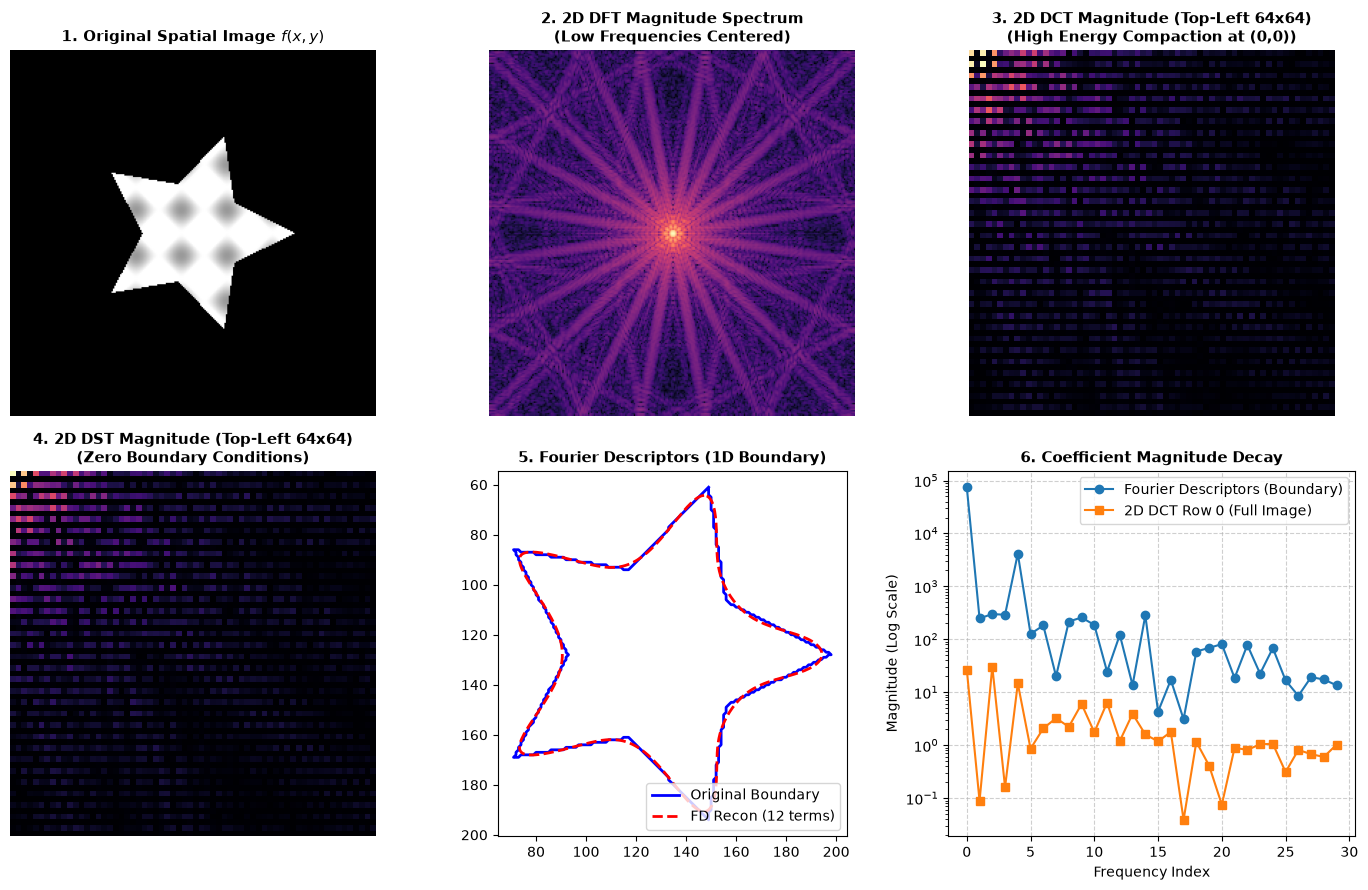

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct, dst

# 1. Generate Synthetic Test Image (Textured star shape)
np.random.seed(42)
img_size = 256
image = np.zeros((img_size, img_size), dtype=np.float32)

center = (128, 128)
radius_outer, radius_inner = 70, 35
num_points = 5
angles = np.linspace(0, 2 * np.pi, num_points * 2, endpoint=False)
poly_pts = []
for i, angle in enumerate(angles):
    r = radius_outer if i % 2 == 0 else radius_inner
    x = int(center[0] + r * np.cos(angle))
    y = int(center[1] + r * np.sin(angle))
    poly_pts.append([x, y])

poly_pts = np.array(poly_pts, dtype=np.int32)
cv2.fillPoly(image, [poly_pts], color=1.0)

# Add smooth wave texture inside the shape
x_grid, y_grid = np.meshgrid(np.linspace(0, 1, img_size), np.linspace(0, 1, img_size))
texture = (np.sin(2 * np.pi * x_grid * 8) + np.cos(2 * np.pi * y_grid * 8)) * 0.2
image = np.clip(image + texture * (image > 0), 0, 1)

# ---------------------------------------------------------
# 2. Compute Transformations
# ---------------------------------------------------------

# A. 2D Discrete Fourier Transform (DFT)
dft_2d = np.fft.fft2(image)
dft_shifted = np.fft.fftshift(dft_2d)
mag_dft = np.log(1 + np.abs(dft_shifted))

# B. 2D Discrete Cosine Transform (DCT-II)
dct_2d = dct(dct(image.T, type=2, norm='ortho').T, type=2, norm='ortho')
mag_dct = np.log(1 + np.abs(dct_2d))

# C. 2D Discrete Sine Transform (DST-II)
dst_2d = dst(dst(image.T, type=2, norm='ortho').T, type=2, norm='ortho')
mag_dst = np.log(1 + np.abs(dst_2d))

# D. Fourier Descriptors (1D Boundary DFT)
binary_mask = (image > 0.2).astype(np.uint8)
contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
cnt = contours[0].squeeze()

# Complex boundary sequence: s(k) = x(k) + j*y(k)
s = cnt[:, 0] + 1j * cnt[:, 1]
fds = np.fft.fft(s)

# Reconstruct shape using only top 12 low-frequency Fourier Descriptors
k_descriptors = 12
fds_truncated = np.zeros_like(fds)
fds_truncated[:k_descriptors] = fds[:k_descriptors]
fds_truncated[-k_descriptors+1:] = fds[-k_descriptors+1:]
s_reconstructed = np.fft.ifft(fds_truncated)

# ---------------------------------------------------------
# 3. Side-by-Side Visualization
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

# Spatial Image
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title("1. Original Spatial Image $f(x,y)$", fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

# 2D DFT
axes[0, 1].imshow(mag_dft, cmap='magma')
axes[0, 1].set_title("2. 2D DFT Magnitude Spectrum\n(Low Frequencies Centered)", fontsize=11, fontweight='bold')
axes[0, 1].axis('off')

# 2D DCT
axes[0, 2].imshow(mag_dct[:64, :64], cmap='magma')
axes[0, 2].set_title("3. 2D DCT Magnitude (Top-Left 64x64)\n(High Energy Compaction at (0,0))", fontsize=11, fontweight='bold')
axes[0, 2].axis('off')

# 2D DST
axes[1, 0].imshow(mag_dst[:64, :64], cmap='magma')
axes[1, 0].set_title("4. 2D DST Magnitude (Top-Left 64x64)\n(Zero Boundary Conditions)", fontsize=11, fontweight='bold')
axes[1, 0].axis('off')

# Fourier Descriptors
axes[1, 1].plot(cnt[:, 0], cnt[:, 1], 'b-', label='Original Boundary', linewidth=2)
axes[1, 1].plot(s_reconstructed.real, s_reconstructed.imag, 'r--', label=f'FD Recon ({k_descriptors} terms)', linewidth=2)
axes[1, 1].set_title("5. Fourier Descriptors (1D Boundary)", fontsize=11, fontweight='bold')
axes[1, 1].invert_yaxis()
axes[1, 1].legend(loc='lower right')
axes[1, 1].set_aspect('equal')

# Decay rate comparison
axes[1, 2].plot(np.abs(fds[:30]), 'o-', label='Fourier Descriptors (Boundary)')
axes[1, 2].plot(np.abs(dct_2d[0, :30]), 's-', label='2D DCT Row 0 (Full Image)')
axes[1, 2].set_title("6. Coefficient Magnitude Decay", fontsize=11, fontweight='bold')
axes[1, 2].set_yscale('log')
axes[1, 2].set_xlabel("Frequency Index")
axes[1, 2].set_ylabel("Magnitude (Log Scale)")
axes[1, 2].grid(True, linestyle='--', alpha=0.6)
axes[1, 2].legend()

plt.tight_layout()
plt.show()